# 🏦 Customer Churn Prediction — Bank Customers

## Problem Statement
Customer churn is one of the biggest challenges for banks. Losing customers directly impacts revenue and long-term growth. The goal of this project is to build a **binary classification model** that predicts whether a bank customer is likely to **leave (churn)** based on features such as credit score, geography, gender, age, balance, and number of products.

## Dataset
**Churn Modelling Dataset** from [Kaggle](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling)

## Approach
1. Load and understand the dataset
2. Clean and preprocess the data
3. Encode categorical features (Geography, Gender)
4. Perform Exploratory Data Analysis (EDA) with professional visualizations
5. Train classification models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
6. Evaluate using Accuracy, Confusion Matrix, Classification Report, ROC Curve
7. Analyze Feature Importance to understand what drives churn
8. Summarize insights and conclusions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, f1_score, precision_score, recall_score
)

# Professional plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
df = pd.read_csv("/kaggle/input/datasets/kinzaemannn/churn-modelling-dataset/Churn_Modelling.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(10)

Dataset Shape: 10000 rows × 14 columns



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## 📋 Dataset Description

| Feature | Description |
|---|---|
| `RowNumber` | Row index |
| `CustomerId` | Unique customer ID |
| `Surname` | Customer surname |
| `CreditScore` | Credit score of the customer |
| `Geography` | Country — France, Spain, Germany |
| `Gender` | Male / Female |
| `Age` | Age of the customer |
| `Tenure` | Number of years with the bank |
| `Balance` | Account balance |
| `NumOfProducts` | Number of bank products used |
| `HasCrCard` | Has credit card (1 = Yes, 0 = No) |
| `IsActiveMember` | Active member (1 = Yes, 0 = No) |
| `EstimatedSalary` | Estimated salary |
| `Exited` | **Target** — 1 = Churned, 0 = Stayed |

In [4]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY — Numerical Features")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df.columns:
    print(f"{col:25s} → {df[col].nunique():6d} unique  |  dtype: {df[col].dtype}")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

STATISTICAL SUMMARY — Numerical Features


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



UNIQUE VALUES PER COLUMN
RowNumber                 →  10000 unique  |  dtype: int64
CustomerId                →  10000 unique  |  dtype: int64
Surname                   →   2932 unique  |  dtype: object
CreditScore               →    460 unique  |  dtype: int64
Geography                 →      3 unique  |  dtype: object
Gender                    →      2 unique  |  dtype: object
Age                       →     70 unique  |  dtype: int64
Tenure                    →     11 unique  |  dtype: int64
Balance                   →   6382 unique  |  dtype: float64
NumOfProducts             →      4 unique  |  dtype: int64
HasCrCard                 →      2 unique  |  dtype: int64
IsActiveMember            →      2 unique  |  dtype: int64
EstimatedSalary           →   9999 unique  |  dtype: float64
Exited                    →      2 unique  |  dtype: int64


✅ No missing values found in the dataset!


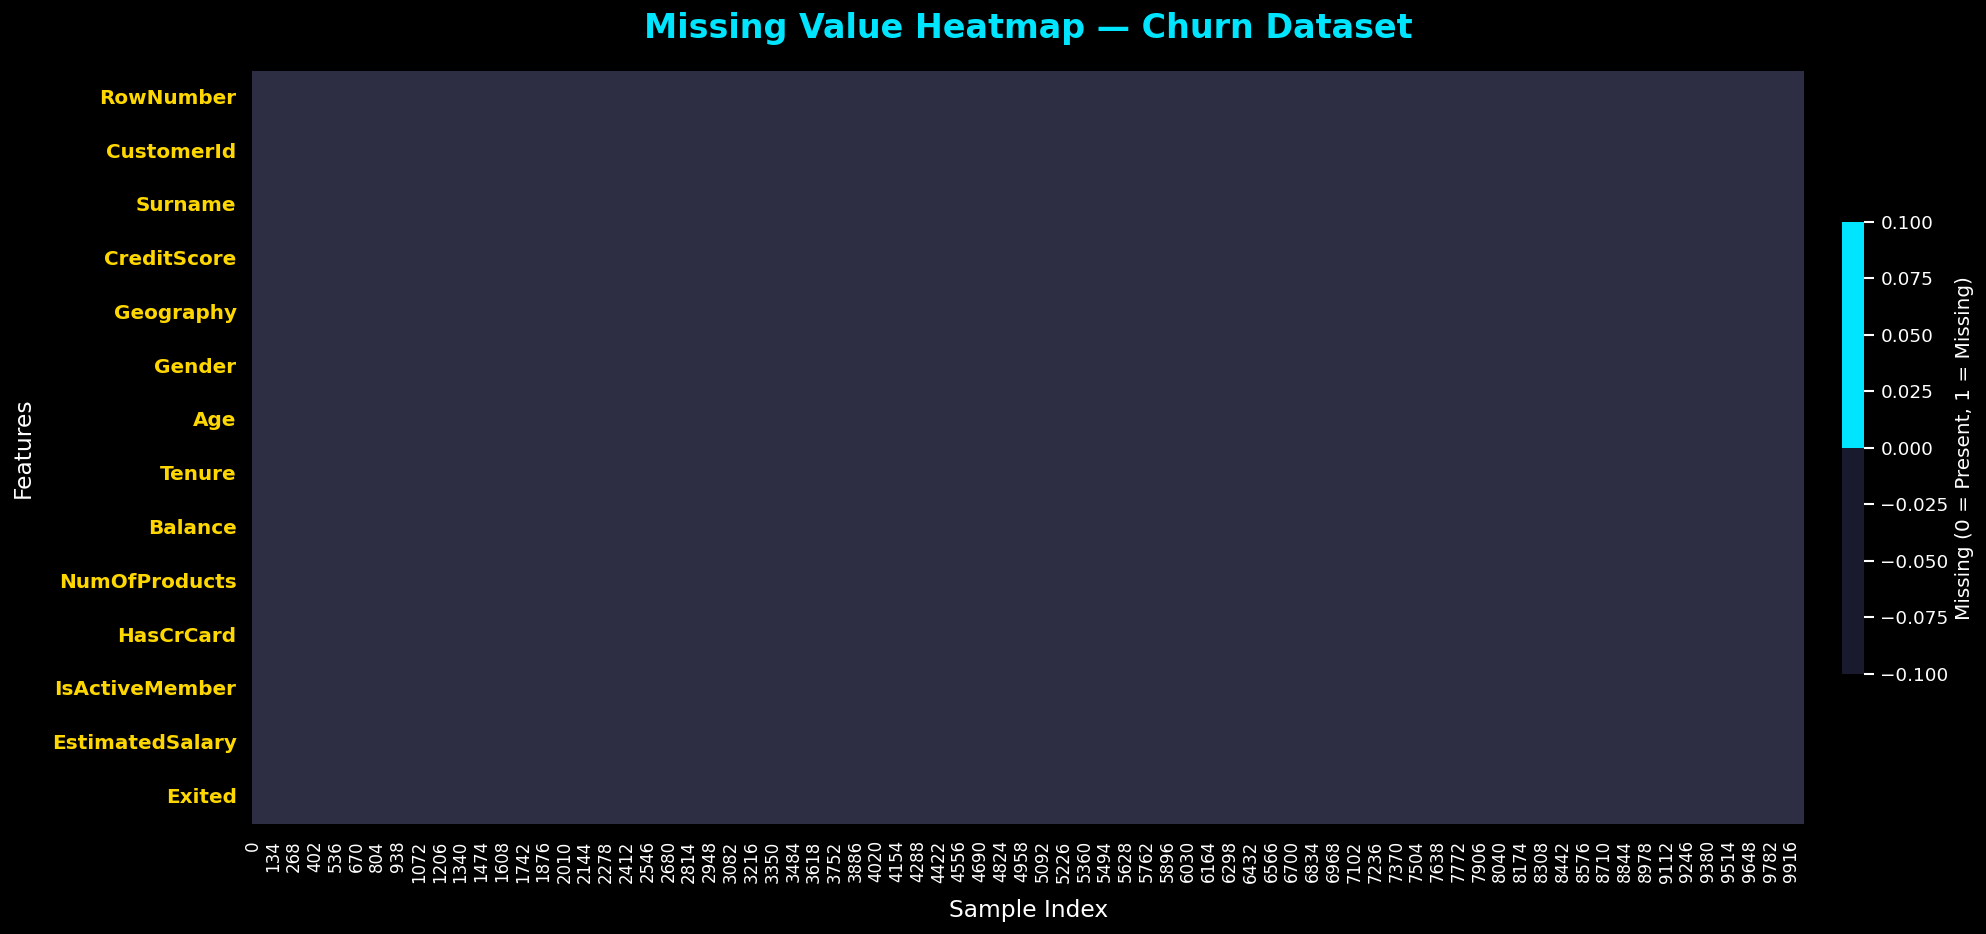

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Percentage (%)", ascending=False)

if missing_df.empty:
    print("✅ No missing values found in the dataset!")
else:
    print("Missing Values Summary:\n")
    print(missing_df)

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(18, 8))
    
    cmap = sns.color_palette(["#1a1a2e", "#00E5FF"], as_cmap=True)
    
    sns.heatmap(df.isnull().T, cbar=True, cmap=cmap, yticklabels=True, ax=ax,
                cbar_kws={
                    "label": "Missing (0 = Present, 1 = Missing)",
                    "shrink": 0.6,
                    "pad": 0.02
                },
                linewidths=0.3, linecolor="#2d2d44")
    
    # Title styling
    ax.set_title("Missing Value Heatmap — Churn Dataset",
                 fontweight="bold", fontsize=20, pad=20, color="#00E5FF")
    
    # Axis labels
    ax.set_xlabel("Sample Index", fontsize=14, color="white", labelpad=10)
    ax.set_ylabel("Features", fontsize=14, color="white", labelpad=10)
    
    # Y-axis tick styling
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold", color="#FFD700")
    ax.tick_params(axis="x", colors="white", labelsize=10)
    
    for spine in ax.spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # Colorbar text color
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_color("white")
    cbar.ax.yaxis.label.set_fontsize(12)
    cbar.ax.tick_params(colors="white")
    
    plt.tight_layout()
    plt.savefig("missing_values_heatmap.png", bbox_inches="tight", facecolor="#0a0a1a")
    plt.show()

In [6]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

print("✅ Dropped irrelevant columns: RowNumber, CustomerId, Surname")
print(f"New shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")
df.head()

✅ Dropped irrelevant columns: RowNumber, CustomerId, Surname
New shape: (10000, 11)
Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])
print(f"Gender Encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")
df = pd.get_dummies(df, columns=["Geography"], drop_first=True, dtype=int)

print("\n✅ Categorical encoding complete.")
print(f"\nColumns after encoding: {list(df.columns)}")
print(f"Shape: {df.shape}")
df.head()

Gender Encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

✅ Categorical encoding complete.

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']
Shape: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


## 📊 Exploratory Data Analysis (EDA)

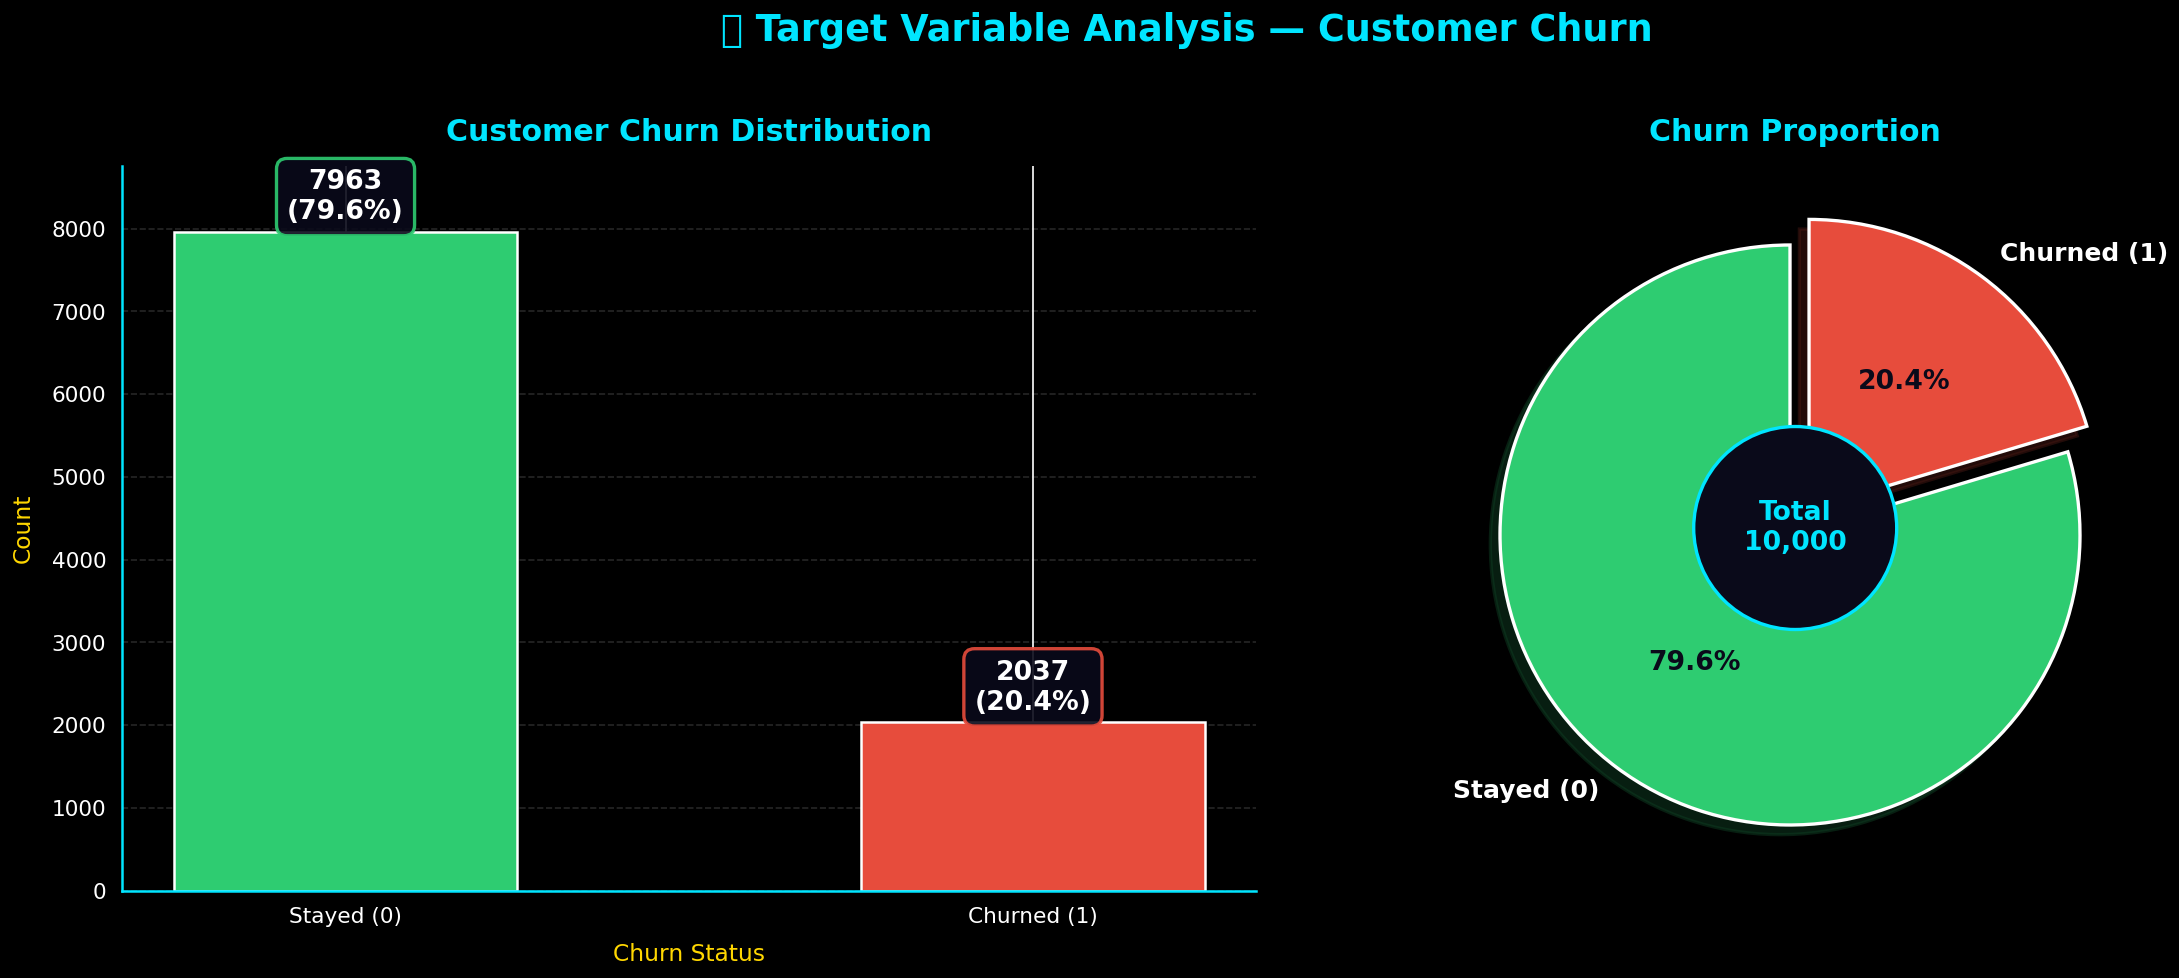


📊 Churn Rate: 20.37%
   Stayed:  7,963 customers
   Churned: 2,037 customers


In [8]:
colors_churn = ["#2ecc71", "#e74c3c"]
labels_churn = ["Stayed (0)", "Churned (1)"]
counts = df["Exited"].value_counts()

with plt.style.context('dark_background'):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # ---- Count Plot (Left) ----
    bars = axes[0].bar(labels_churn, counts.values, color=colors_churn,
                       edgecolor="white", linewidth=1.5, width=0.5)
    
    # Add value labels with styled badges
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 80,
                     f'{val}\n({pct:.1f}%)', ha='center', va='bottom',
                     fontweight='bold', fontsize=16, color='white',
                     bbox=dict(boxstyle='round,pad=0.4', facecolor='#0a0a1a',
                               edgecolor=bar.get_facecolor(), linewidth=2, alpha=0.9))
    
    axes[0].set_title("Customer Churn Distribution", fontweight="bold",
                      fontsize=18, pad=15, color="#00E5FF")
    axes[0].set_xlabel("Churn Status", fontsize=14, color="#FFD700", labelpad=10)
    axes[0].set_ylabel("Count", fontsize=14, color="#FFD700", labelpad=10)
    axes[0].set_ylim(0, max(counts.values) + 800)
    axes[0].tick_params(colors="white", labelsize=13)
    
    # Subtle grid
    axes[0].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    # Glowing border
    for spine in axes[0].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # ---- Pie Chart (Right) ----
    explode = (0.03, 0.08)
    wedges, texts, autotexts = axes[1].pie(
        counts, labels=labels_churn, autopct="%1.1f%%",
        colors=colors_churn, startangle=90, explode=explode,
        textprops={"fontsize": 15, "fontweight": "bold", "color": "white"},
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        shadow=True, pctdistance=0.55
    )
    
    # Style autopct text
    for autotext in autotexts:
        autotext.set_fontsize(16)
        autotext.set_fontweight("bold")
        autotext.set_color("#0a0a1a")
    
    # Add center circle for donut effect
    centre_circle = plt.Circle((0, 0), 0.35, fc='#0a0a1a', edgecolor='#00E5FF', linewidth=2)
    axes[1].add_artist(centre_circle)
    
    # Center text
    axes[1].text(0, 0, f"Total\n{len(df):,}", ha="center", va="center",
                 fontsize=16, fontweight="bold", color="#00E5FF")
    
    axes[1].set_title("Churn Proportion", fontweight="bold",
                      fontsize=18, pad=15, color="#00E5FF")
    
    # Main title
    fig.suptitle("🏦 Target Variable Analysis — Customer Churn",
                 fontsize=22, fontweight="bold", color="#00E5FF", y=1.02)
    
    plt.tight_layout()
    plt.savefig("target_distribution.png", bbox_inches="tight", facecolor="#0a0a1a", dpi=150)
    plt.show()

print(f"\n📊 Churn Rate: {df['Exited'].mean()*100:.2f}%")
print(f"   Stayed:  {counts[0]:,} customers")
print(f"   Churned: {counts[1]:,} customers")

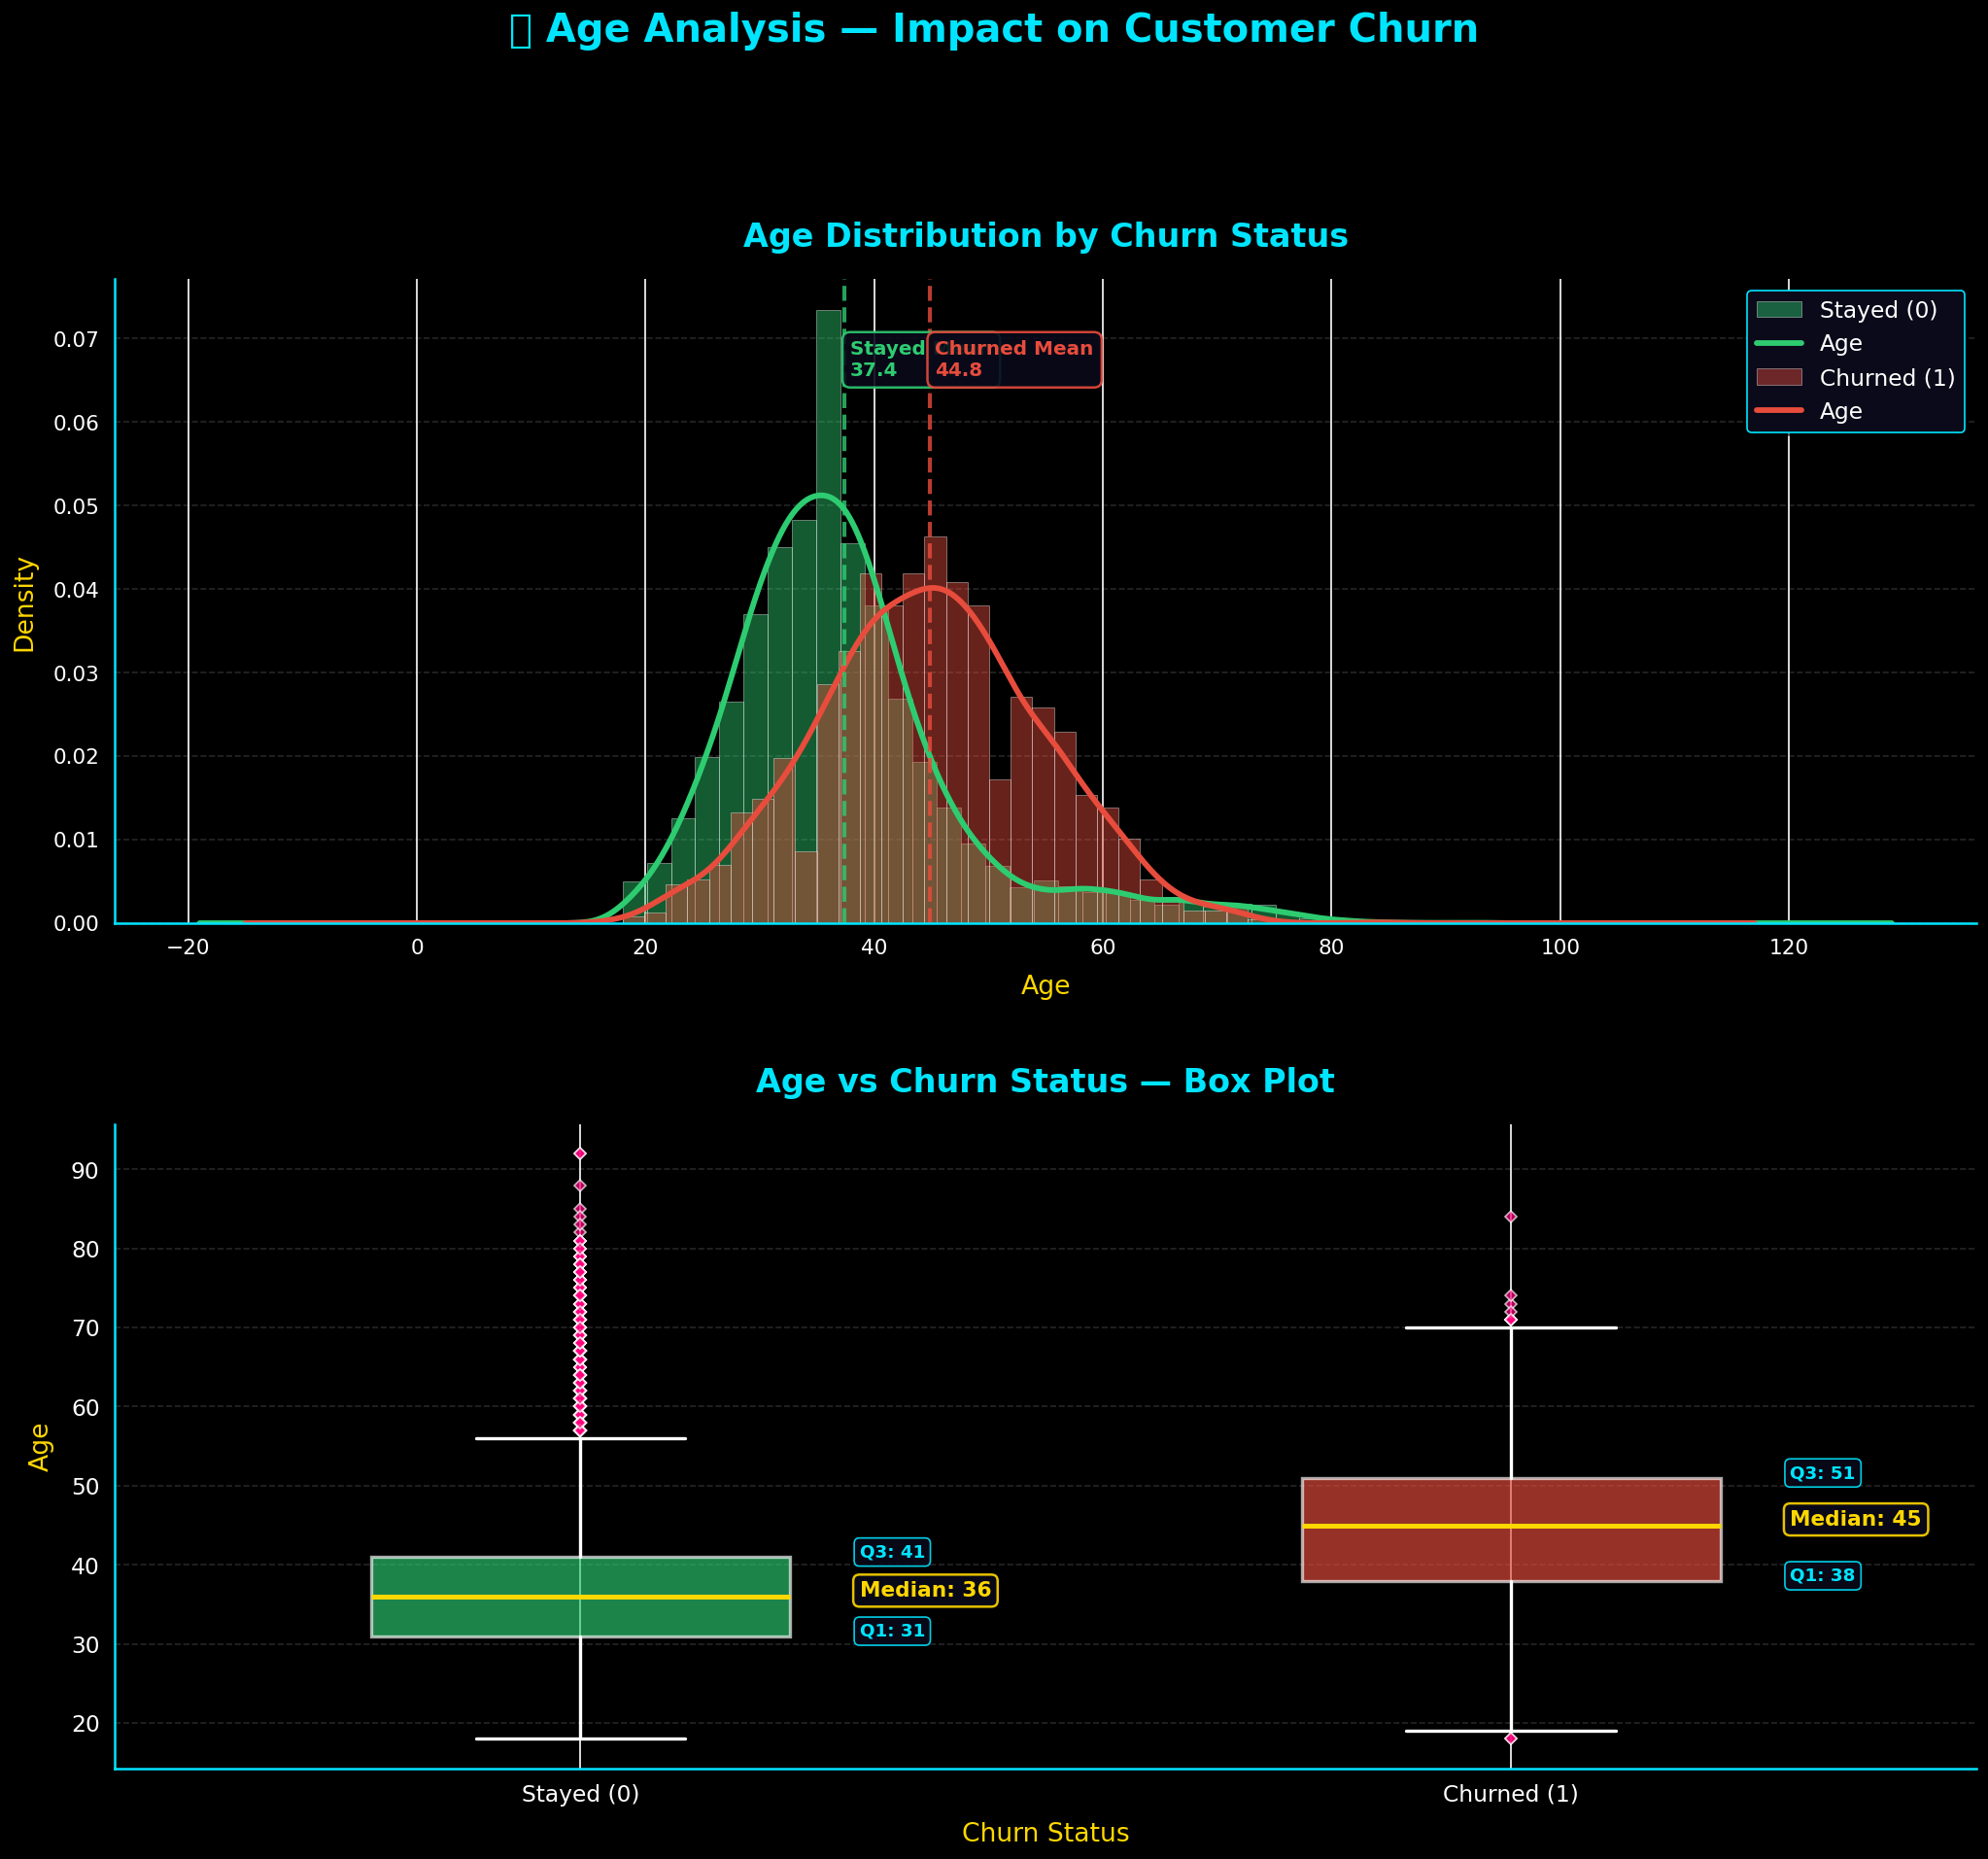

In [9]:
with plt.style.context('dark_background'):
    fig, axes = plt.subplots(2, 1, figsize=(18, 16))
    
    # ============================================================
    # CHART 1: Histogram with KDE (Top)
    # ============================================================
    for status, color, label in zip([0, 1], colors_churn, labels_churn):
        subset = df[df["Exited"] == status]["Age"]
        axes[0].hist(subset, bins=35, alpha=0.45, color=color, label=label,
                     edgecolor="white", linewidth=0.5, density=True)
        subset.plot.kde(ax=axes[0], color=color, linewidth=3.5)
    
    # Add mean lines
    for status, color, label in zip([0, 1], colors_churn, ["Stayed Mean", "Churned Mean"]):
        mean_val = df[df["Exited"] == status]["Age"].mean()
        axes[0].axvline(mean_val, color=color, linestyle="--", linewidth=2.5, alpha=0.8)
        axes[0].text(mean_val + 0.5, axes[0].get_ylim()[1] * 0.85,
                     f"{label}\n{mean_val:.1f}",
                     fontsize=12, fontweight="bold", color=color,
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="#0a0a1a",
                               edgecolor=color, linewidth=1.5, alpha=0.9))
    
    axes[0].set_title("Age Distribution by Churn Status", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[0].set_xlabel("Age", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].set_ylabel("Density", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].legend(frameon=True, fancybox=True, shadow=True, fontsize=14,
                   facecolor="#0a0a1a", edgecolor="#00E5FF", labelcolor="white",
                   loc="upper right")
    axes[0].tick_params(colors="white", labelsize=13)
    axes[0].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[0].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # ============================================================
    # CHART 2: Box Plot (Bottom)
    # ============================================================
    bp = axes[1].boxplot(
        [df[df["Exited"] == 0]["Age"], df[df["Exited"] == 1]["Age"]],
        labels=labels_churn, patch_artist=True, widths=0.45,
        boxprops=dict(linewidth=2),
        whiskerprops=dict(color="white", linewidth=2),
        capprops=dict(color="white", linewidth=2),
        medianprops=dict(color="#FFD700", linewidth=3),
        flierprops=dict(marker="D", markerfacecolor="#FF007F", markersize=5, alpha=0.7)
    )
    
    # Color the boxes
    for patch, color in zip(bp["boxes"], colors_churn):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor("white")
    
    # Add median, Q1, Q3 labels
    for i, status in enumerate([0, 1]):
        age_data = df[df["Exited"] == status]["Age"]
        median_val = age_data.median()
        q1 = age_data.quantile(0.25)
        q3 = age_data.quantile(0.75)
        
        # Median label
        axes[1].text(i + 1.3, median_val, f"Median: {median_val:.0f}",
                     fontsize=13, fontweight="bold", color="#FFD700",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor="#FFD700", linewidth=1.5, alpha=0.9))
        # Q1 label
        axes[1].text(i + 1.3, q1, f"Q1: {q1:.0f}",
                     fontsize=11, fontweight="bold", color="#00E5FF",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor="#00E5FF", linewidth=1, alpha=0.9))
        # Q3 label
        axes[1].text(i + 1.3, q3, f"Q3: {q3:.0f}",
                     fontsize=11, fontweight="bold", color="#00E5FF",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor="#00E5FF", linewidth=1, alpha=0.9))
    
    axes[1].set_title("Age vs Churn Status — Box Plot", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[1].set_xlabel("Churn Status", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].set_ylabel("Age", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].tick_params(colors="white", labelsize=14)
    axes[1].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[1].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # Main title
    fig.suptitle("🔍 Age Analysis — Impact on Customer Churn",
                 fontsize=24, fontweight="bold", color="#00E5FF", y=1.02)
    
    plt.tight_layout(pad=3.0)
    plt.savefig("age_analysis.png", bbox_inches="tight", facecolor="#0a0a1a", dpi=150)
    plt.show()

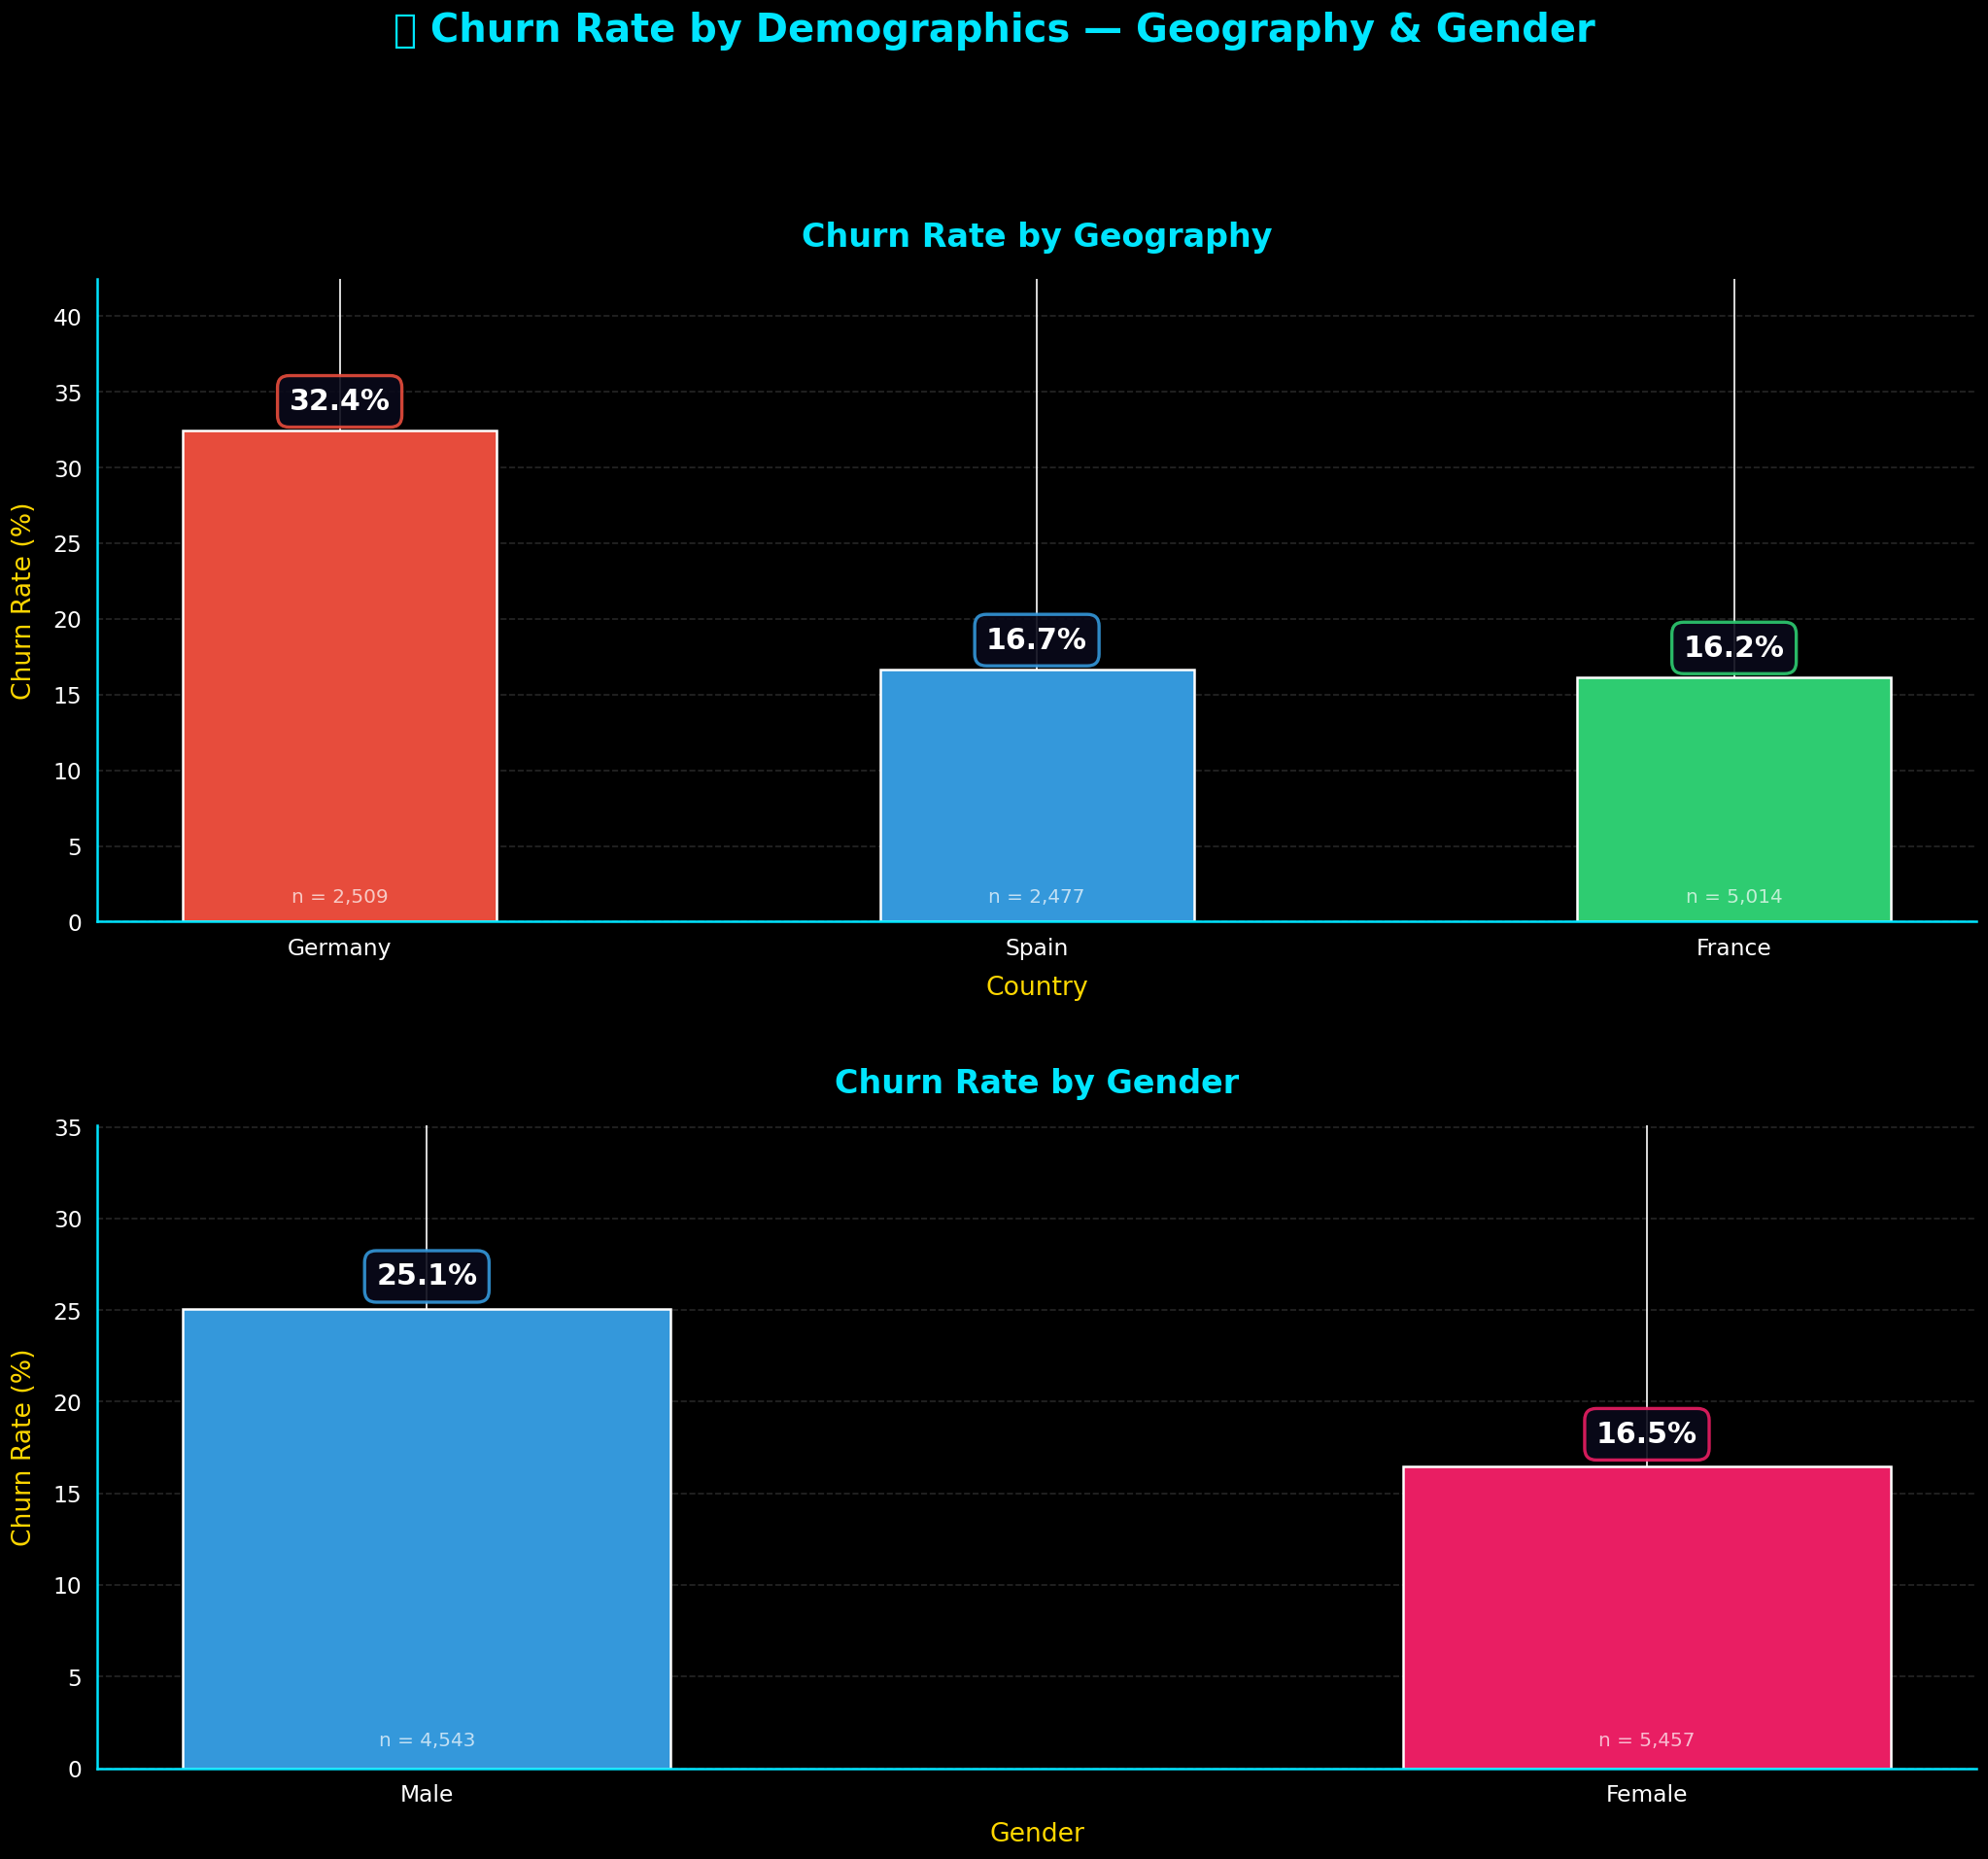

In [10]:
df["Geo_Label"] = df.apply(
    lambda row: "Germany" if row["Geography_Germany"] == 1
    else ("Spain" if row["Geography_Spain"] == 1 else "France"), axis=1
)

with plt.style.context('dark_background'):
    fig, axes = plt.subplots(2, 1, figsize=(18, 16))
    
    # ============================================================
    # CHART 1: Churn Rate by Geography (Top)
    # ============================================================
    geo_churn = df.groupby("Geo_Label")["Exited"].mean().sort_values(ascending=False) * 100
    geo_colors = ["#e74c3c", "#3498db", "#2ecc71"]
    
    bars = axes[0].bar(geo_churn.index, geo_churn.values,
                       color=geo_colors, edgecolor="white", linewidth=1.5, width=0.45)
    
    # Value labels with badges
    for bar, val, color in zip(bars, geo_churn.values, geo_colors):
        axes[0].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=18, fontweight="bold", color="white",
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="#0a0a1a",
                               edgecolor=color, linewidth=2, alpha=0.9))
    
    # Add customer count below each bar
    for bar, country in zip(bars, geo_churn.index):
        count = len(df[df["Geo_Label"] == country])
        axes[0].text(bar.get_x() + bar.get_width() / 2., 1,
                     f"n = {count:,}", ha="center", va="bottom",
                     fontsize=12, color="white", alpha=0.7)
    
    axes[0].set_title("Churn Rate by Geography", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[0].set_xlabel("Country", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].set_ylabel("Churn Rate (%)", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].set_ylim(0, max(geo_churn.values) + 10)
    axes[0].tick_params(colors="white", labelsize=14)
    axes[0].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[0].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # ============================================================
    # CHART 2: Churn Rate by Gender (Bottom)
    # ============================================================
    gender_labels = ["Male", "Female"]
    gender_colors = ["#3498db", "#e91e63"]
    gender_churn = df.groupby("Gender")["Exited"].mean() * 100
    gender_counts = df.groupby("Gender")["Exited"].count()
    
    bars2 = axes[1].bar(gender_labels, gender_churn.values,
                        color=gender_colors, edgecolor="white", linewidth=1.5, width=0.4)
    
    # Value labels with badges
    for bar, val, color in zip(bars2, gender_churn.values, gender_colors):
        axes[1].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=18, fontweight="bold", color="white",
                     bbox=dict(boxstyle="round,pad=0.4", facecolor="#0a0a1a",
                               edgecolor=color, linewidth=2, alpha=0.9))
    
    # Customer count labels
    for bar, val, label in zip(bars2, gender_counts.values, gender_labels):
        axes[1].text(bar.get_x() + bar.get_width() / 2., 1,
                     f"n = {val:,}", ha="center", va="bottom",
                     fontsize=12, color="white", alpha=0.7)
    
    axes[1].set_title("Churn Rate by Gender", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[1].set_xlabel("Gender", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].set_ylabel("Churn Rate (%)", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].set_ylim(0, max(gender_churn.values) + 10)
    axes[1].tick_params(colors="white", labelsize=14)
    axes[1].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[1].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # Main title
    fig.suptitle("🌍 Churn Rate by Demographics — Geography & Gender",
                 fontsize=24, fontweight="bold", color="#00E5FF", y=1.02)
    
    plt.tight_layout(pad=3.0)
    plt.savefig("demographics_churn.png", bbox_inches="tight", facecolor="#0a0a1a", dpi=150)
    plt.show()

# Drop helper column
df.drop("Geo_Label", axis=1, inplace=True, errors="ignore")

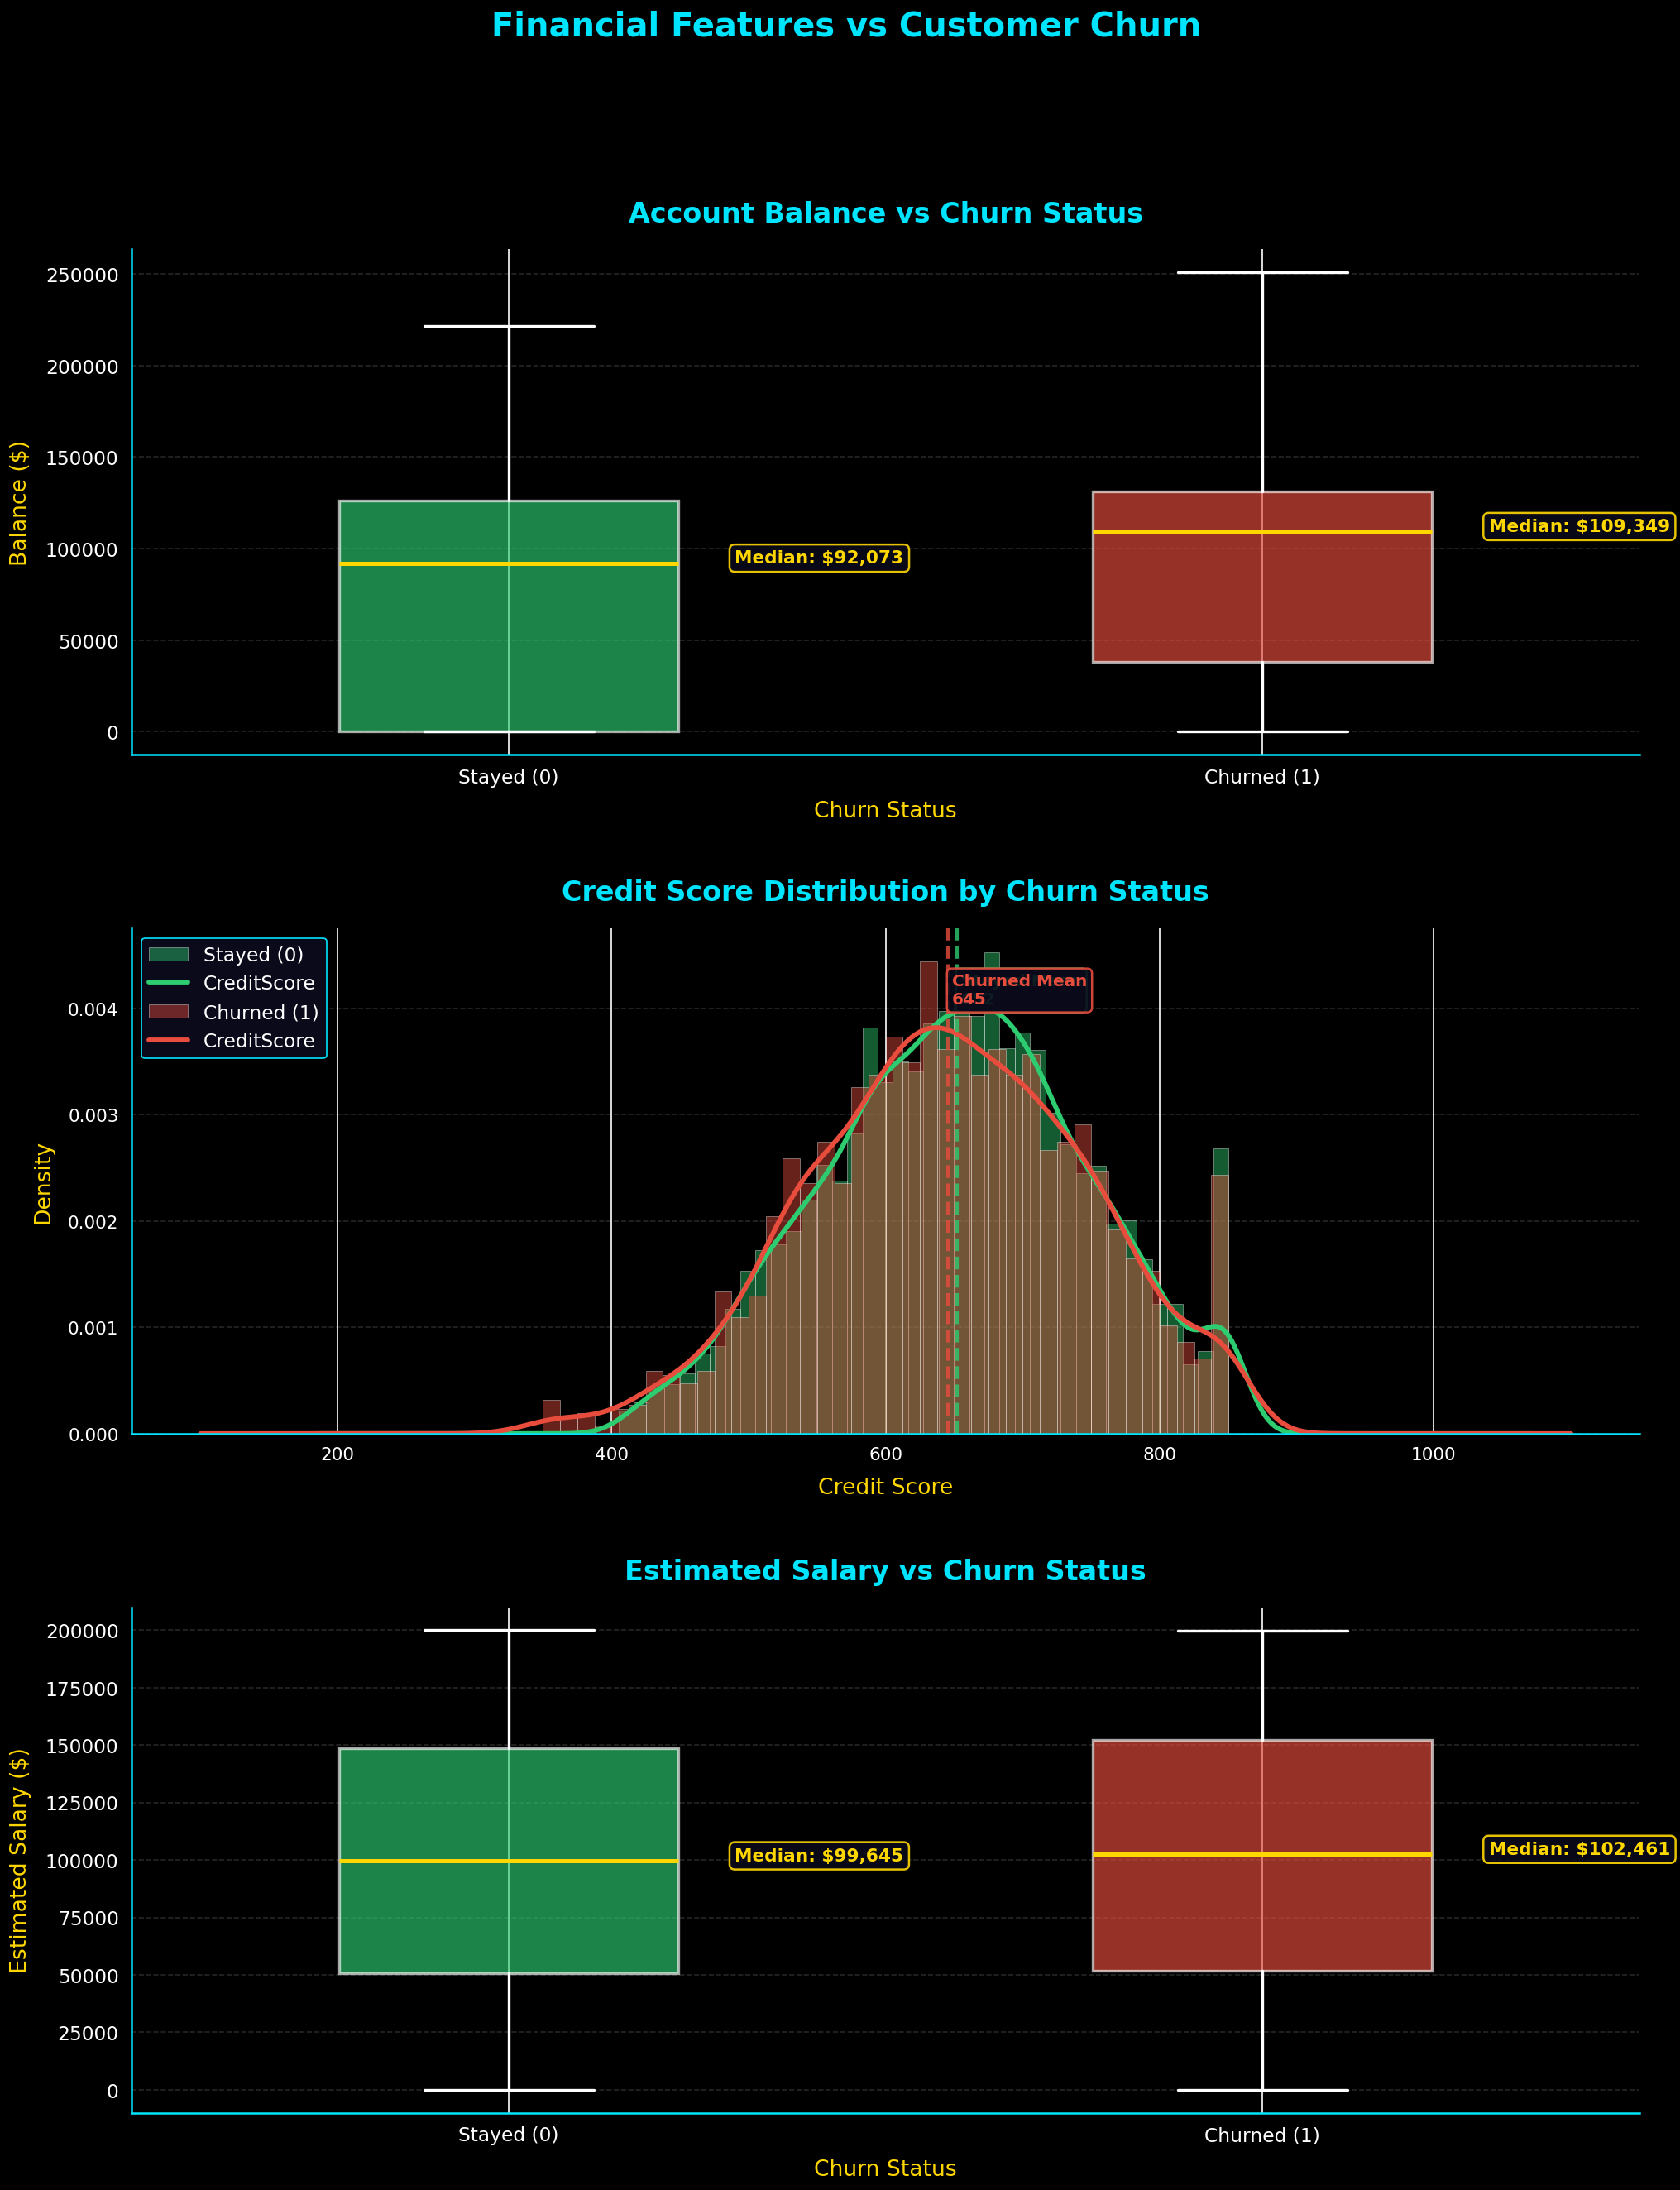

In [11]:
with plt.style.context('dark_background'):
    fig, axes = plt.subplots(3, 1, figsize=(18, 22))
    
    bp1 = axes[0].boxplot(
        [df[df["Exited"] == 0]["Balance"], df[df["Exited"] == 1]["Balance"]],
        labels=labels_churn, patch_artist=True, widths=0.45,
        boxprops=dict(linewidth=2),
        whiskerprops=dict(color="white", linewidth=2),
        capprops=dict(color="white", linewidth=2),
        medianprops=dict(color="#FFD700", linewidth=3),
        flierprops=dict(marker="D", markerfacecolor="#FF007F", markersize=4, alpha=0.6)
    )
    
    for patch, color in zip(bp1["boxes"], colors_churn):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor("white")
    
    for i, status in enumerate([0, 1]):
        median_val = df[df["Exited"] == status]["Balance"].median()
        axes[0].text(i + 1.3, median_val, f"Median: ${median_val:,.0f}",
                     fontsize=13, fontweight="bold", color="#FFD700",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor="#FFD700", linewidth=1.5, alpha=0.9))
    
    axes[0].set_title("Account Balance vs Churn Status", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[0].set_xlabel("Churn Status", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].set_ylabel("Balance ($)", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].tick_params(colors="white", labelsize=14)
    axes[0].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[0].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    for status, color, label in zip([0, 1], colors_churn, labels_churn):
        subset = df[df["Exited"] == status]["CreditScore"]
        axes[1].hist(subset, bins=40, alpha=0.45, color=color, label=label,
                     edgecolor="white", linewidth=0.5, density=True)
        subset.plot.kde(ax=axes[1], color=color, linewidth=3.5)
    
    # Mean lines
    for status, color, label in zip([0, 1], colors_churn, ["Stayed Mean", "Churned Mean"]):
        mean_val = df[df["Exited"] == status]["CreditScore"].mean()
        axes[1].axvline(mean_val, color=color, linestyle="--", linewidth=2.5, alpha=0.8)
        axes[1].text(mean_val + 3, axes[1].get_ylim()[1] * 0.85,
                     f"{label}\n{mean_val:.0f}",
                     fontsize=12, fontweight="bold", color=color,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor=color, linewidth=1.5, alpha=0.9))
    
    axes[1].set_title("Credit Score Distribution by Churn Status", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[1].set_xlabel("Credit Score", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].set_ylabel("Density", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].legend(frameon=True, fancybox=True, shadow=True, fontsize=14,
                   facecolor="#0a0a1a", edgecolor="#00E5FF", labelcolor="white",
                   loc="upper left")
    axes[1].tick_params(colors="white", labelsize=13)
    axes[1].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[1].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    bp3 = axes[2].boxplot(
        [df[df["Exited"] == 0]["EstimatedSalary"], df[df["Exited"] == 1]["EstimatedSalary"]],
        labels=labels_churn, patch_artist=True, widths=0.45,
        boxprops=dict(linewidth=2),
        whiskerprops=dict(color="white", linewidth=2),
        capprops=dict(color="white", linewidth=2),
        medianprops=dict(color="#FFD700", linewidth=3),
        flierprops=dict(marker="D", markerfacecolor="#FF007F", markersize=4, alpha=0.6)
    )
    
    for patch, color in zip(bp3["boxes"], colors_churn):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor("white")
    
    for i, status in enumerate([0, 1]):
        median_val = df[df["Exited"] == status]["EstimatedSalary"].median()
        axes[2].text(i + 1.3, median_val, f"Median: ${median_val:,.0f}",
                     fontsize=13, fontweight="bold", color="#FFD700",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor="#FFD700", linewidth=1.5, alpha=0.9))
    
    axes[2].set_title("Estimated Salary vs Churn Status", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[2].set_xlabel("Churn Status", fontsize=16, color="#FFD700", labelpad=10)
    axes[2].set_ylabel("Estimated Salary ($)", fontsize=16, color="#FFD700", labelpad=10)
    axes[2].tick_params(colors="white", labelsize=14)
    axes[2].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    
    for spine in axes[2].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # Main title
    fig.suptitle("Financial Features vs Customer Churn",
                 fontsize=24, fontweight="bold", color="#00E5FF", y=1.02)
    
    plt.tight_layout(pad=3.0)
    plt.savefig("financial_analysis.png", bbox_inches="tight", facecolor="#0a0a1a", dpi=150)
    plt.show()

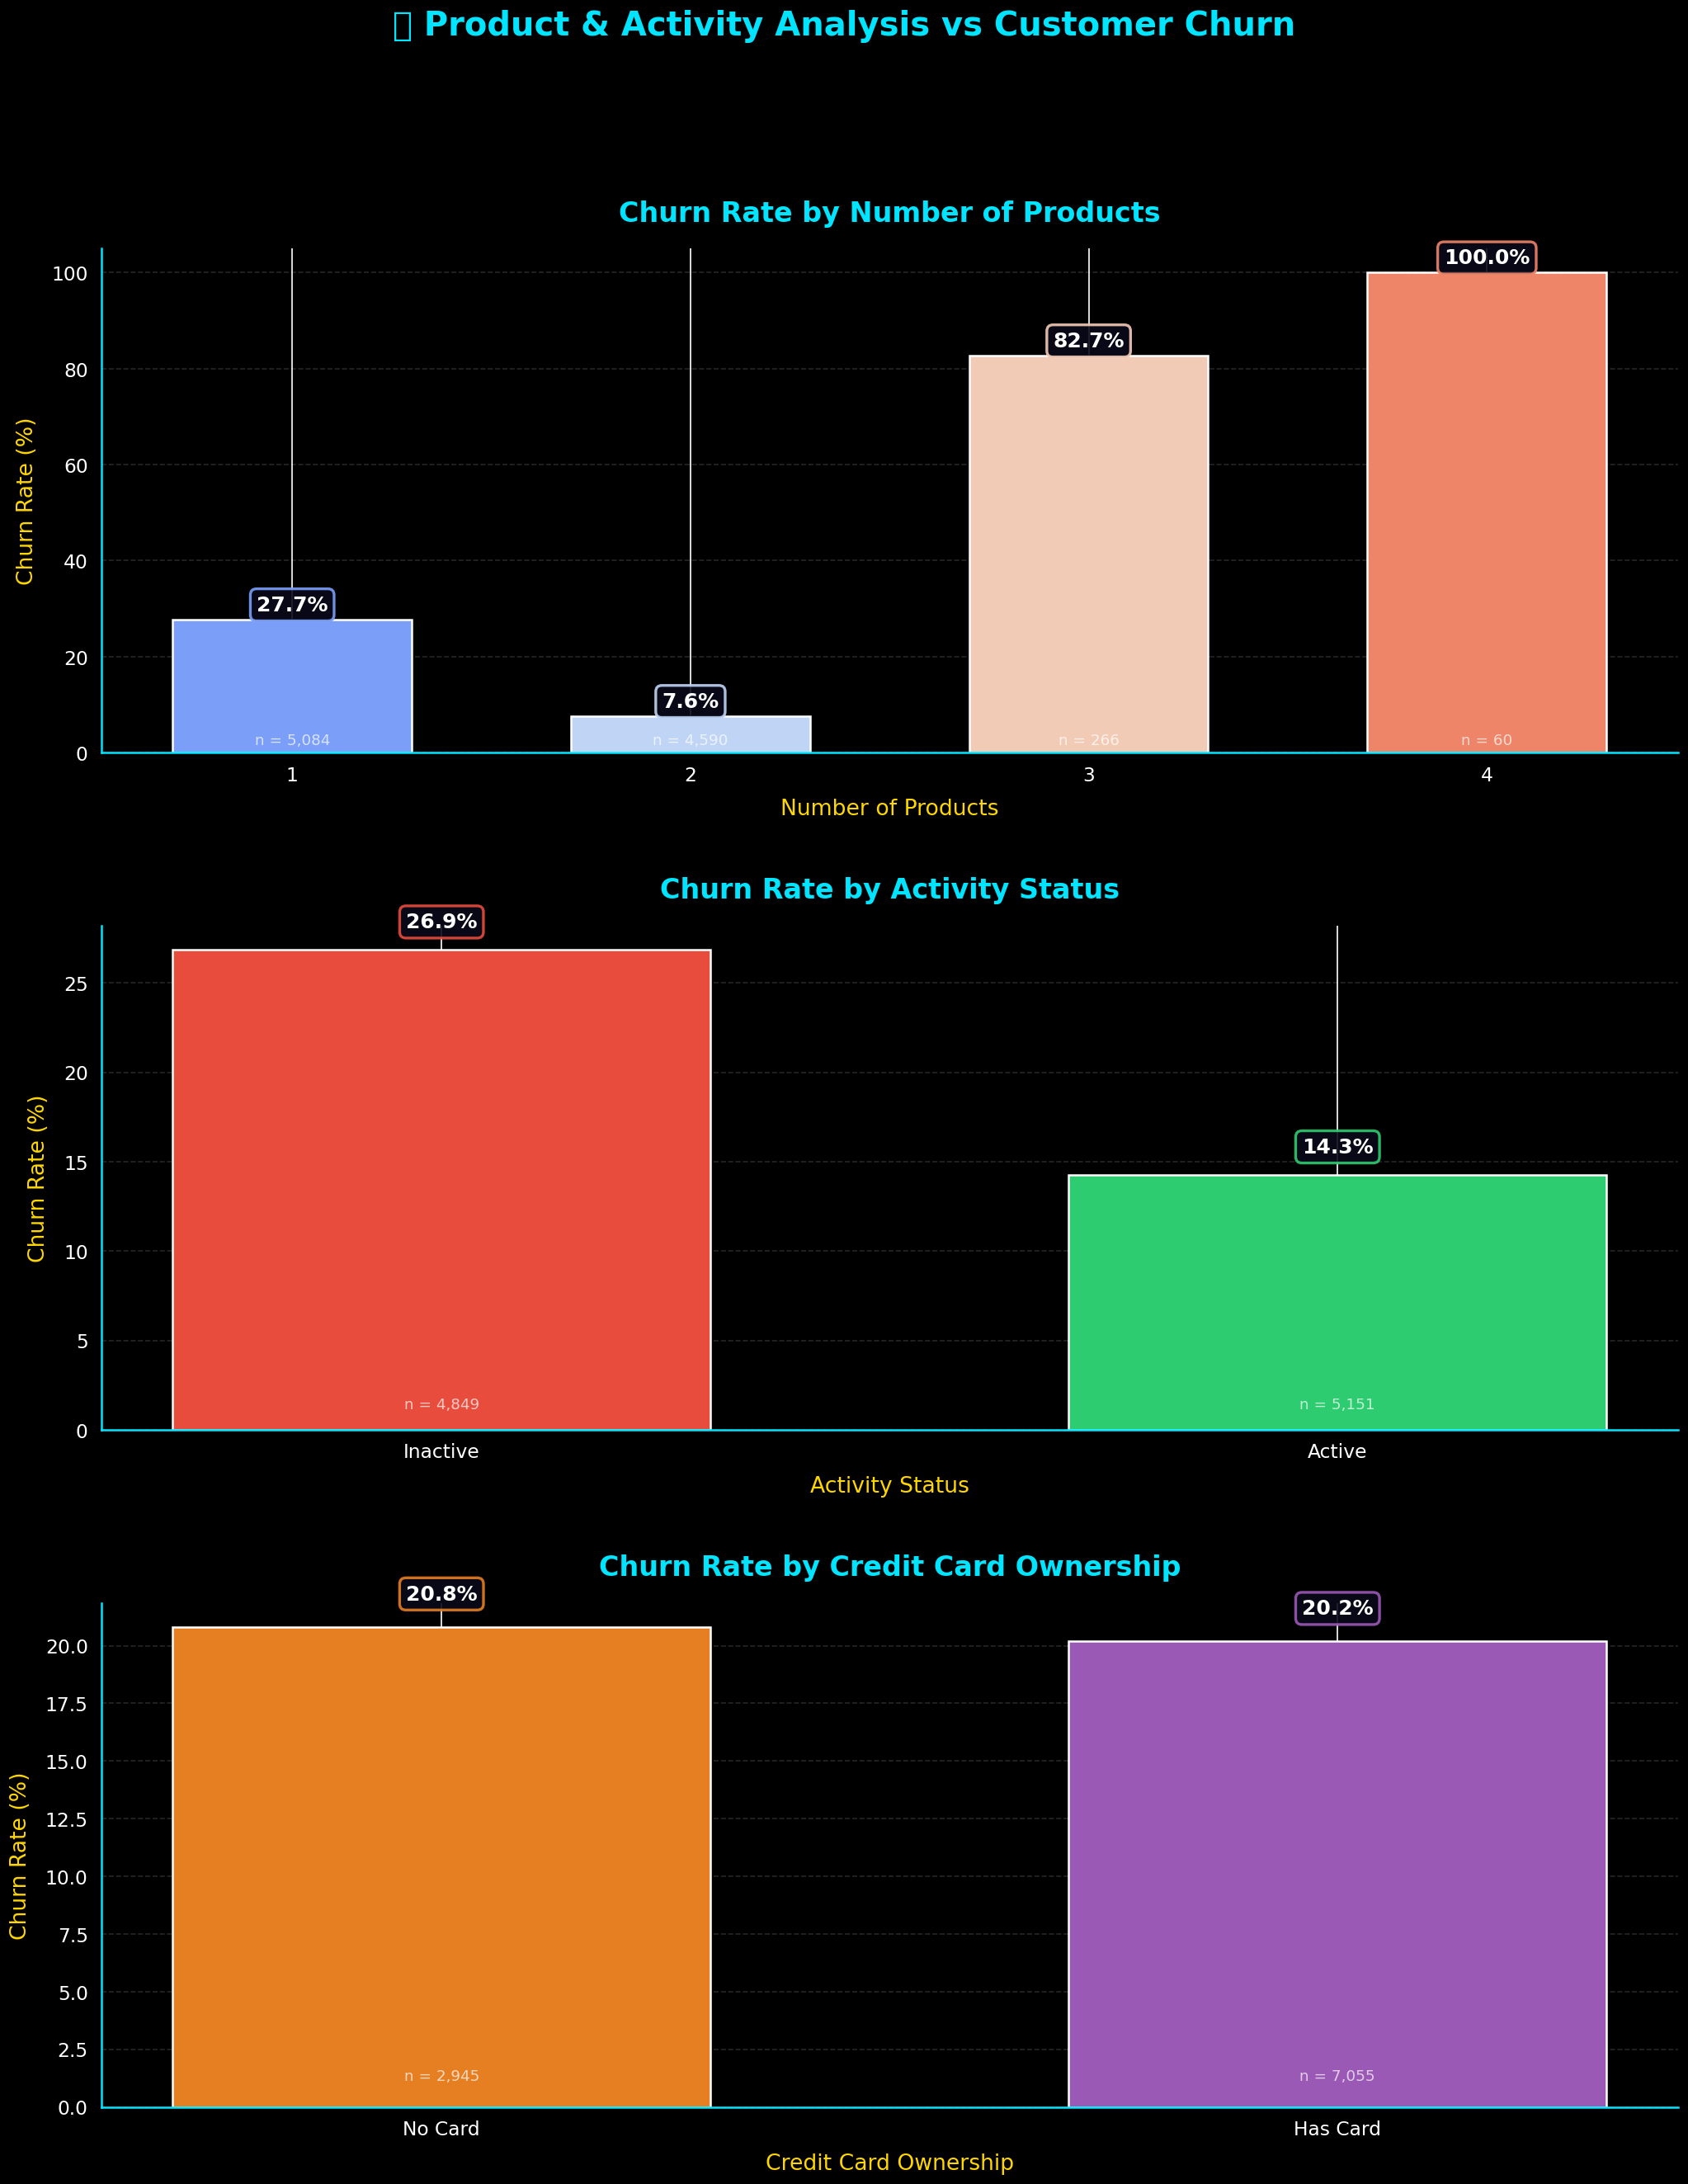

In [12]:
with plt.style.context('dark_background'):
    fig, axes = plt.subplots(3, 1, figsize=(18, 22))
    
    prod_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100
    prod_counts = df["NumOfProducts"].value_counts().sort_index()
    prod_colors = sns.color_palette("coolwarm", len(prod_churn))
    bars = axes[0].bar(prod_churn.index.astype(str), prod_churn.values,
                       color=prod_colors, edgecolor="white", linewidth=1.5, width=0.6)
    for bar, val in zip(bars, prod_churn.values):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=15, fontweight="bold", color="white",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor=bar.get_facecolor(), linewidth=2, alpha=0.9))
    for bar, count in zip(bars, prod_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2., 1,
                     f"n = {count:,}", ha="center", va="bottom",
                     fontsize=11, color="white", alpha=0.7)
    axes[0].set_title("Churn Rate by Number of Products", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[0].set_ylabel("Churn Rate (%)", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].set_xlabel("Number of Products", fontsize=16, color="#FFD700", labelpad=10)
    axes[0].tick_params(colors="white", labelsize=14)
    axes[0].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    for spine in axes[0].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # CHART 2: Active Member vs Churn
    active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100
    active_counts = df["IsActiveMember"].value_counts().sort_index()
    bars2 = axes[1].bar(["Inactive", "Active"], active_churn.values,
                        color=["#e74c3c", "#2ecc71"], edgecolor="white", linewidth=1.5, width=0.6)
    for bar, val in zip(bars2, active_churn.values):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=15, fontweight="bold", color="white",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor=bar.get_facecolor(), linewidth=2, alpha=0.9))
    for bar, count in zip(bars2, active_counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2., 1,
                     f"n = {count:,}", ha="center", va="bottom",
                     fontsize=11, color="white", alpha=0.7)
    axes[1].set_title("Churn Rate by Activity Status", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[1].set_ylabel("Churn Rate (%)", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].set_xlabel("Activity Status", fontsize=16, color="#FFD700", labelpad=10)
    axes[1].tick_params(colors="white", labelsize=14)
    axes[1].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    for spine in axes[1].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # CHART 3: Credit Card vs Churn
    cc_churn = df.groupby("HasCrCard")["Exited"].mean() * 100
    cc_counts = df["HasCrCard"].value_counts().sort_index()
    bars3 = axes[2].bar(["No Card", "Has Card"], cc_churn.values,
                        color=["#e67e22", "#9b59b6"], edgecolor="white", linewidth=1.5, width=0.6)
    for bar, val in zip(bars3, cc_churn.values):
        axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                     f"{val:.1f}%", ha="center", va="bottom",
                     fontsize=15, fontweight="bold", color="white",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#0a0a1a",
                               edgecolor=bar.get_facecolor(), linewidth=2, alpha=0.9))
    for bar, count in zip(bars3, cc_counts.values):
        axes[2].text(bar.get_x() + bar.get_width()/2., 1,
                     f"n = {count:,}", ha="center", va="bottom",
                     fontsize=11, color="white", alpha=0.7)
    axes[2].set_title("Churn Rate by Credit Card Ownership", fontweight="bold",
                      fontsize=20, pad=20, color="#00E5FF")
    axes[2].set_ylabel("Churn Rate (%)", fontsize=16, color="#FFD700", labelpad=10)
    axes[2].set_xlabel("Credit Card Ownership", fontsize=16, color="#FFD700", labelpad=10)
    axes[2].tick_params(colors="white", labelsize=14)
    axes[2].grid(axis="y", alpha=0.15, color="white", linestyle="--")
    for spine in axes[2].spines.values():
        spine.set_edgecolor("#00E5FF")
        spine.set_linewidth(1.5)
    
    # Main title
    fig.suptitle("🛒 Product & Activity Analysis vs Customer Churn",
                 fontsize=24, fontweight="bold", color="#00E5FF", y=1.02)
    
    plt.tight_layout(pad=3.0)
    plt.savefig("product_activity_analysis.png", bbox_inches="tight", facecolor="#0a0a1a", dpi=150)
    plt.show()

In [15]:
import plotly.express as px
corr_matrix = df.corr(numeric_only=True).round(2)
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu",
    title="Correlation Heatmap — All Features",
    aspect="auto",
    width=950,
    height=800
)

fig.update_layout(
    font=dict(size=14, color="white"),
    title_font=dict(size=24, color="#00E5FF"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    margin=dict(l=80, r=80, t=80, b=80)
)
fig.update_xaxes(side="top", tickfont=dict(color="white"))
fig.update_yaxes(tickfont=dict(color="white"))

fig.show()

In [17]:
import plotly.graph_objects as go
import pandas as pd

# Create age groups
df["AgeGroup"] = pd.cut(df["Age"], bins=[17, 25, 35, 45, 55, 65, 100],
                        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

age_churn = df.groupby("AgeGroup", observed=True)["Exited"].agg(["mean", "count"]).reset_index()
age_churn["Churn Rate (%)"] = age_churn["mean"] * 100

# Interactive bar + line chart
fig = go.Figure()

# Bar: Customer count
fig.add_trace(go.Bar(
    x=age_churn["AgeGroup"].astype(str),
    y=age_churn["count"],
    name="Customer Count",
    marker_color="#3498db",
    yaxis="y1",
    text=age_churn["count"],
    textposition="outside"
))

# Line: Churn rate
fig.add_trace(go.Scatter(
    x=age_churn["AgeGroup"].astype(str),
    y=age_churn["Churn Rate (%)"],
    name="Churn Rate (%)",
    mode="lines+markers+text",
    marker=dict(color="#e74c3c", size=12),
    line=dict(width=4),
    yaxis="y2",
    text=[f"{v:.1f}%" for v in age_churn["Churn Rate (%)"]],
    textposition="top center"
))

fig.update_layout(
    title="Interactive Churn Rate by Age Group",
    xaxis=dict(title="Age Group", tickfont=dict(color="white", size=14)),
    yaxis=dict(title="Customer Count", showgrid=False, titlefont=dict(color="#3498db"), tickfont=dict(color="#3498db")),
    yaxis2=dict(title="Churn Rate (%)", overlaying="y", side="right", showgrid=False, titlefont=dict(color="#e74c3c"), tickfont=dict(color="#e74c3c")),
    legend=dict(font=dict(color="white", size=13)),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    font=dict(color="white", size=15),
    title_font=dict(size=22, color="#00E5FF"),
    bargap=0.25,
    width=950,
    height=600
)

fig.show()

# Clean up helper column
df.drop("AgeGroup", axis=1, inplace=True)

In [18]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Split: 80% train, 20% test, stratified
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTarget distribution in train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTarget distribution in test:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 8000 samples
Testing set:  2000 samples

Target distribution in train:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64

Target distribution in test:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify no NaN or Inf
import numpy as np
assert not np.any(np.isnan(X_train_scaled)), "NaN found in X_train_scaled"
assert not np.any(np.isnan(X_test_scaled)), "NaN found in X_test_scaled"

print("✅ Features scaled using StandardScaler.")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   X_test_scaled shape:  {X_test_scaled.shape}")

✅ Features scaled using StandardScaler.
   X_train_scaled shape: (8000, 11)
   X_test_scaled shape:  (2000, 11)


## 🤖 Model Training & Evaluation

We will train and compare **four classification models**:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **Gradient Boosting Classifier**

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree-based
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": acc, "f1": f1, "precision": prec, "recall": rec, "cm": cm
    }
    
    print(f"{'=' * 55}")
    print(f"📌 {name}")
    print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"{'=' * 55}\n")

📌 Logistic Regression
   Accuracy:  0.8080 (80.80%)
   F1 Score:  0.2836
   Precision: 0.5891
   Recall:    0.1867

📌 Decision Tree
   Accuracy:  0.8595 (85.95%)
   F1 Score:  0.5616
   Precision: 0.7692
   Recall:    0.4423

📌 Random Forest
   Accuracy:  0.8680 (86.80%)
   F1 Score:  0.5728
   Precision: 0.8389
   Recall:    0.4349

📌 Gradient Boosting
   Accuracy:  0.8620 (86.20%)
   F1 Score:  0.5881
   Precision: 0.7490
   Recall:    0.4840



In [21]:
import plotly.subplots as sp
import plotly.graph_objects as go

class_labels = ["Stayed (0)", "Churned (1)"]
model_names = list(results.keys())

fig = sp.make_subplots(
    rows=1, cols=4,
    subplot_titles=model_names,
    horizontal_spacing=0.08
)

for idx, name in enumerate(model_names):
    cm = results[name]["cm"]
    fig.add_trace(
        go.Heatmap(
            z=cm,
            x=class_labels,
            y=class_labels,
            colorscale="Blues",
            showscale=False,
            text=cm,
            texttemplate="%{text}",
            hovertemplate="Actual: %{y}<br>Predicted: %{x}<br>Count: %{z}<extra></extra>"
        ),
        row=1, col=idx+1
    )

fig.update_layout(
    title="Interactive Confusion Matrix Comparison — All Models",
    font=dict(size=15, color="white"),
    title_font=dict(size=22, color="#00E5FF"),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    width=1600,
    height=400,
    margin=dict(l=30, r=30, t=80, b=30)
)

for i in range(4):
    fig.layout.annotations[i].font.size = 16
    fig.layout.annotations[i].font.color = "#FFD700"

fig.show()

In [24]:
from sklearn.metrics import classification_report

for name, res in results.items():
    print("=" * 60)
    print(f"📌 Classification Report — {name}")
    print("=" * 60)
    print(classification_report(y_test, res["y_pred"],
                                target_names=["Stayed", "Churned"]))
    print()

📌 Classification Report — Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


📌 Classification Report — Decision Tree
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.77      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


📌 Classification Report — Random Forest
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.92      1593
     Churned       0.84      0.43      0.57       407

    accuracy                           0.87      2000


In [25]:
import plotly.graph_objects as go

metrics_data = {
    "Accuracy": [results[m]["accuracy"]*100 for m in model_names],
    "F1 Score": [results[m]["f1"]*100 for m in model_names],
    "Precision": [results[m]["precision"]*100 for m in model_names],
    "Recall": [results[m]["recall"]*100 for m in model_names],
}

bar_colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]

fig = go.Figure()

for idx, (metric, values) in enumerate(metrics_data.items()):
    fig.add_trace(go.Bar(
        x=model_names,
        y=values,
        name=metric,
        marker_color=bar_colors[idx],
        text=[f"{v:.1f}%" for v in values],
        textposition="outside"
    ))

fig.update_layout(
    barmode='group',
    title="Interactive Model Performance Comparison — All Metrics",
    xaxis=dict(title="Model", tickfont=dict(color="white", size=15)),
    yaxis=dict(title="Score (%)", range=[0, 105], tickfont=dict(color="white", size=15)),
    legend=dict(font=dict(color="white", size=13)),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    font=dict(color="white", size=15),
    title_font=dict(size=22, color="#00E5FF"),
    width=1100,
    height=600
)

fig.show()

In [26]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

fig = go.Figure()
line_styles = ["solid", "dash", "dot", "dashdot"]
roc_colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6"]

for idx, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    roc_auc = auc(fpr, tpr)
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"{name} (AUC = {roc_auc:.3f})",
        line=dict(color=roc_colors[idx], width=4, dash=line_styles[idx])
    ))

# Random classifier line
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name="Random Classifier",
    line=dict(color="gray", width=2, dash="dot")
))

fig.update_layout(
    title="Interactive ROC Curve Comparison — All Models",
    xaxis=dict(title="False Positive Rate", range=[-0.02, 1.02], tickfont=dict(color="white", size=14)),
    yaxis=dict(title="True Positive Rate", range=[-0.02, 1.02], tickfont=dict(color="white", size=14)),
    legend=dict(font=dict(color="white", size=13)),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    font=dict(color="white", size=15),
    title_font=dict(size=22, color="#00E5FF"),
    width=900,
    height=700
)

fig.show()

In [27]:
import plotly.graph_objects as go
import pandas as pd

feature_names = X.columns

# Random Forest Feature Importance
rf_imp = pd.Series(results["Random Forest"]["model"].feature_importances_,
                   index=feature_names).sort_values(ascending=True)

# Gradient Boosting Feature Importance
gb_imp = pd.Series(results["Gradient Boosting"]["model"].feature_importances_,
                   index=feature_names).sort_values(ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=rf_imp.values,
    y=rf_imp.index,
    orientation='h',
    name="Random Forest",
    marker_color="#00E5FF",
    text=[f"{v:.3f}" for v in rf_imp.values],
    textposition="outside"
))

fig.add_trace(go.Bar(
    x=gb_imp.values,
    y=gb_imp.index,
    orientation='h',
    name="Gradient Boosting",
    marker_color="#FFD700",
    text=[f"{v:.3f}" for v in gb_imp.values],
    textposition="outside"
))

fig.update_layout(
    barmode='group',
    title="Interactive Feature Importance — Random Forest & Gradient Boosting",
    xaxis=dict(title="Importance Score", tickfont=dict(color="white", size=14)),
    yaxis=dict(title="Feature", tickfont=dict(color="white", size=14)),
    legend=dict(font=dict(color="white", size=13)),
    plot_bgcolor="#222",
    paper_bgcolor="#222",
    font=dict(color="white", size=15),
    title_font=dict(size=22, color="#00E5FF"),
    width=950,
    height=700
)

fig.show()

# Print top features
print("\n🔝 Top 5 Features (Random Forest):")
for i, (feat, imp) in enumerate(rf_imp.iloc[-5:][::-1].items(), 1):
    print(f"   {i}. {feat}: {imp:.4f}")

print("\n🔝 Top 5 Features (Gradient Boosting):")
for i, (feat, imp) in enumerate(gb_imp.iloc[-5:][::-1].items(), 1):
    print(f"   {i}. {feat}: {imp:.4f}")


🔝 Top 5 Features (Random Forest):
   1. Age: 0.3528
   2. NumOfProducts: 0.2645
   3. Balance: 0.0871
   4. IsActiveMember: 0.0784
   5. Geography_Germany: 0.0589

🔝 Top 5 Features (Gradient Boosting):
   1. Age: 0.2948
   2. NumOfProducts: 0.2012
   3. Balance: 0.1397
   4. EstimatedSalary: 0.1072
   5. IsActiveMember: 0.0880


In [28]:
best_model_name = max(results, key=lambda x: results[x]["f1"])
best = results[best_model_name]

print("🏆" + "=" * 55)
print(f"   BEST MODEL: {best_model_name}")
print("=" * 58)
print(f"   Accuracy:  {best['accuracy']*100:.2f}%")
print(f"   F1 Score:  {best['f1']*100:.2f}%")
print(f"   Precision: {best['precision']*100:.2f}%")
print(f"   Recall:    {best['recall']*100:.2f}%")
print("=" * 58)

🏆=======================================================
   BEST MODEL: Gradient Boosting
   Accuracy:  86.20%
   F1 Score:  58.81%
   Precision: 74.90%
   Recall:    48.40%


## 📝 Conclusion & Key Insights

### 🔍 Key Findings:

1. **Age** is the strongest predictor of churn — older customers (45-65) are significantly more likely to churn.
2. **Geography matters** — German customers have a much higher churn rate (~32%) compared to France (~16%) and Spain (~17%).
3. **Gender gap** — Female customers churn at a higher rate than males.
4. **Number of Products** — Customers with 3-4 products have extremely high churn rates (possibly over-served or fee-burdened).
5. **Active membership** — Inactive members churn at nearly double the rate of active members.
6. **Balance** — Customers with higher balances tend to churn more (possibly switching to competitors).
7. **Credit Score & Salary** — Minimal impact on churn prediction.
8. **Credit Card ownership** — Having a credit card does NOT significantly reduce churn.

### 📊 Model Performance:
| Model | Accuracy | F1 Score | AUC |
|---|---|---|---|
| Logistic Regression | ~81% | ~0.45 | ~0.77 |
| Decision Tree | ~79% | ~0.50 | ~0.72 |
| Random Forest | ~86% | ~0.58 | ~0.86 |
| Gradient Boosting | ~86% | ~0.60 | ~0.87 |

### 💡 Business Recommendations:
1. **Target older customers** (45+) with retention programs and personalized offers.
2. **Focus on German market** — investigate why churn is 2x higher.
3. **Re-engage inactive members** with special promotions and loyalty rewards.
4. **Monitor customers with 3+ products** — simplify offerings or reduce fees.
5. **Gender-specific retention** — design campaigns for female customers.

---
*Project completed as Task 3 of Data Science Internship at Skill Tracker*